# Environment (GPU + installs)

In [1]:
!nvidia-smi
%pip -q install torch torchvision torchaudio torchmetrics scikit-learn matplotlib pandas numpy tqdm einops textwrap3

Mon Nov 10 17:17:44 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# Imports & Global Configurations

In [2]:
import os, re, glob, math, random, time, json, zipfile, textwrap
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.cuda.amp import autocast, GradScaler
from torchvision.utils import make_grid
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score, average_precision_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from einops import rearrange

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
OUTDIR = Path('/content/outputs'); OUTDIR.mkdir(parents=True, exist_ok=True)
DATADIR = Path('/content/data'); DATADIR.mkdir(parents=True, exist_ok=True)

print("Device:", DEVICE)
print("OUTDIR:", OUTDIR)

Device: cuda
OUTDIR: /content/outputs


# Mounting Drive & Extracting Dataset from Uploaded Zip

In [3]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_ZIP_PATH = '/content/drive/MyDrive/DeepLearning_2.zip'
print("Found zip:", DRIVE_ZIP_PATH)

if DRIVE_ZIP_PATH:
    with zipfile.ZipFile(DRIVE_ZIP_PATH, 'r') as zf:
        zf.extractall(DATADIR)
    print("Extracted to:", DATADIR)
    print("Top-level entries:", os.listdir(DATADIR)[:10])

Mounted at /content/drive
Found zip: /content/drive/MyDrive/DeepLearning_2.zip
Extracted to: /content/data
Top-level entries: ['organization.csv', 'independent-contractor.csv', 'registration-rights.csv', 'amendments-and-waivers.csv', 'term-of-employment.csv', 'indebtedness.csv', 'transfer.csv', 'now-therefore.csv', 'time.csv', 'r-e-c-i-t-a-l-s.csv']


# Configuratons & Reproducibility

In [4]:
cfg = {
    "project_name": "legal-clause-similarity",
    "max_vocab": 30000,
    "min_freq": 2,
    "max_len": 128,
    "batch_size": 128,
    "num_workers": 0,
    "epochs": 12,
    "lr": 3e-4,
    "weight_decay": 1e-4,
    "amp": True,
    "pair_pos_ratio": 1.0,
    "val_split": 0.1,
    "test_split": 0.1,
    "seed": 1337
}

def set_seed(seed=1337):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.backends.cudnn.benchmark = True
    try: torch.set_float32_matmul_precision('high')
    except: pass

set_seed(cfg["seed"]); print("Seeded and TF32 enabled.")
cfg

Seeded and TF32 enabled.


{'project_name': 'legal-clause-similarity',
 'max_vocab': 30000,
 'min_freq': 2,
 'max_len': 128,
 'batch_size': 128,
 'num_workers': 0,
 'epochs': 12,
 'lr': 0.0003,
 'weight_decay': 0.0001,
 'amp': True,
 'pair_pos_ratio': 1.0,
 'val_split': 0.1,
 'test_split': 0.1,
 'seed': 1337}

# Loading all CSVs

In [5]:
# We expect multiple CSV files, each representing a clause category.
# Robust loader: discovers CSVs anywhere under DATADIR, merges them,
# and tries to infer 'text' and 'label/type' columns.

def find_csvs(root: Path):
    return sorted([Path(p) for p in glob.glob(str(root / '**/*.csv'), recursive=True)])

def read_one_csv(path: Path):
    df = pd.read_csv(path)
    df.columns = [c.strip().lower().replace(' ', '_') for c in df.columns]
    # Try to detect text column
    text_col_candidates = [c for c in df.columns if c in ['text','clause','clause_text','sentence','content']]
    if not text_col_candidates:
        # fallback: longest stringy column
        text_col_candidates = [max(df.columns, key=lambda c: df[c].astype(str).str.len().mean())]
    text_col = text_col_candidates[0]

    # Try to detect type/label column
    type_col_candidates = [c for c in df.columns if c in ['type','label','clause_type','category']]
    type_col = type_col_candidates[0] if type_col_candidates else None

    df = df[[text_col] + ([type_col] if type_col else [])].copy()
    df.rename(columns={text_col:'text', (type_col if type_col else 'text'):'type'}, inplace=True)
    if 'type' not in df.columns:
        df['type'] = path.stem  # fallback: use file name as type/category
    df['category_file'] = path.stem
    return df

csvs = find_csvs(DATADIR)
if not csvs:
    raise RuntimeError(f"No CSVs found under {DATADIR}. Please ensure the zip extracted CSV files.")
dfs = [read_one_csv(p) for p in csvs]
raw = pd.concat(dfs, ignore_index=True)
raw.dropna(subset=['text'], inplace=True)
raw['text'] = raw['text'].astype(str).str.strip()
raw = raw[raw['text'].str.len() > 0].reset_index(drop=True)

print("Loaded rows:", len(raw), "from", len(csvs), "files")
raw.head(3)

Loaded rows: 150881 from 395 files


,text,type,category_file
0,Absence of Certain Changes or Events. Except a...,absence-of-certain-changes-or-events,absence-of-certain-changes-or-events
1,Absence of Certain Changes or Events. Since Ma...,absence-of-certain-changes-or-events,absence-of-certain-changes-or-events
2,Absence of Certain Changes or Events. (a) Sinc...,absence-of-certain-changes-or-events,absence-of-certain-changes-or-events


# Basic Cleaning & Spliting (train/val/test)

In [6]:
def clean_text(s: str):
    s = re.sub(r'\s+', ' ', s)
    s = s.replace('\u00A0',' ').strip()
    return s

raw['text'] = raw['text'].map(clean_text)

# Stratify by 'type' (if meaningful) else by file category
stratify_key = raw['type'] if raw['type'].nunique() > 1 else raw['category_file']

# Shuffle
raw = raw.sample(frac=1.0, random_state=cfg["seed"]).reset_index(drop=True)

# Splits
n = len(raw)
n_test = int(n * cfg["test_split"])
n_val  = int(n * cfg["val_split"])
n_train = n - n_test - n_val

train_df = raw.iloc[:n_train].reset_index(drop=True)
val_df   = raw.iloc[n_train:n_train+n_val].reset_index(drop=True)
test_df  = raw.iloc[n_train+n_val:].reset_index(drop=True)

for name, df in [('train',train_df), ('val',val_df), ('test',test_df)]:
    print(name, len(df))

train 120705
val 15088
test 15088


In [7]:
train_df.head()

,text,type,category_file
0,Purchase and Sale. (1) The introductory paragr...,purchase-and-sale,purchase-and-sale
1,Resignation. If the Executive's employment is ...,resignation,resignation
2,Amendment. This Agreement may not be amended o...,amendment,amendment
3,Remedies Cumulative. Each of the various right...,remedies-cumulative,remedies-cumulative
4,Documents. Seller shall have received all of t...,documents,documents


# Tokenizer & Vocabulary (from scratch, no transformers)

In [8]:
# Simple whitespace/punctuation-aware tokenizer
def basic_tokenize(s: str):
    # lowercase + split on non-letters/numbers; keep apostrophes/dashes inside words
    s = s.lower()
    tokens = re.findall(r"[a-z0-9]+(?:['\-][a-z0-9]+)?", s)
    return tokens

# Build vocab on TRAIN ONLY
counter = Counter()
for t in train_df['text']:
    counter.update(basic_tokenize(t))

# Keep tokens by frequency
itos = ['<pad>','<unk>','<bos>','<eos>']
for tok, cnt in counter.most_common():
    if cnt < cfg["min_freq"]:
        continue
    itos.append(tok)
    if len(itos) >= cfg["max_vocab"]:
        break
stoi = {t:i for i,t in enumerate(itos)}

PAD, UNK, BOS, EOS = 0,1,2,3

def encode_text(s: str, max_len=128):
    toks = [BOS] + [stoi.get(t, UNK) for t in basic_tokenize(s)] + [EOS]
    if len(toks) < max_len:
        toks = toks + [PAD]*(max_len - len(toks))
    else:
        toks = toks[:max_len]
    return np.array(toks, dtype=np.int64)

vocab_size = len(itos)
print("Vocab size:", vocab_size)
print("Sample encode:", encode_text(train_df['text'].iloc[0], cfg["max_len"])[:20])

Vocab size: 27834
Sample encode: [   2  178    7  269   65    4 6176 1706    5   15   17   41   94  691
  215   15   17   18   44  613]


# Pair Dataset (Positives/Negatives) & DataLoaders

In [9]:
# Positive pair: clauses with the SAME 'type' label (semantic equivalence proxy)
# Negative pair: clauses with DIFFERENT 'type' (or different file categories if type not available)

def make_pairs(df: pd.DataFrame, pos_ratio=1.0, max_len=128, seed=1337):
    rnd = random.Random(seed)
    by_type = defaultdict(list)
    for i, row in df.iterrows():
        by_type[row['type']].append(i)

    indices = list(range(len(df)))
    pos_pairs, neg_pairs = [], []

    # Build positives within each type (random pairs)
    for t, idxs in by_type.items():
        if len(idxs) < 2:
            continue
        rnd.shuffle(idxs)
        for i in range(0, len(idxs)-1, 2):
            pos_pairs.append((idxs[i], idxs[i+1], 1))

    # Build negatives by mixing across types
    types = list(by_type.keys())
    if len(types) > 1:
        all_idxs = indices.copy()
        rnd.shuffle(all_idxs)
        for i in range(0, len(all_idxs)-1, 2):
            a, b = all_idxs[i], all_idxs[i+1]
            if df.loc[a, 'type'] != df.loc[b, 'type']:
                neg_pairs.append((a,b,0))

    # Balance by pos_ratio
    k = int(len(pos_pairs) * (1/pos_ratio - 1)) if pos_ratio < 1.0 else len(neg_pairs)
    if len(neg_pairs) > len(pos_pairs):
        neg_pairs = neg_pairs[:len(pos_pairs)]
    else:
        pos_pairs = pos_pairs[:len(neg_pairs)]

    pairs = pos_pairs + neg_pairs
    rnd.shuffle(pairs)

    # Materialize encoded arrays to speed-up
    enc = [encode_text(s, max_len) for s in df['text'].tolist()]
    return pairs, enc

train_pairs, train_enc = make_pairs(train_df, pos_ratio=cfg["pair_pos_ratio"], max_len=cfg["max_len"], seed=cfg["seed"])
val_pairs,   val_enc   = make_pairs(val_df,   pos_ratio=1.0, max_len=cfg["max_len"], seed=cfg["seed"])
test_pairs,  test_enc  = make_pairs(test_df,  pos_ratio=1.0, max_len=cfg["max_len"], seed=cfg["seed"])

len(train_pairs), len(val_pairs), len(test_pairs)

(120404, 14886, 14894)

# PyTorch Dataset/DataLoader

In [10]:
class PairDataset(Dataset):
    def __init__(self, enc_list, pairs):
        self.enc = enc_list
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        a, b, y = self.pairs[idx]
        x1 = torch.from_numpy(self.enc[a])
        x2 = torch.from_numpy(self.enc[b])
        y  = torch.tensor(y, dtype=torch.float32)
        return x1, x2, y

def make_loader(enc, pairs, bs, nw, shuffle):
    return DataLoader(PairDataset(enc, pairs), batch_size=bs, shuffle=shuffle,
                      num_workers=nw, pin_memory=True, drop_last=shuffle)

dl_train = make_loader(train_enc, train_pairs, cfg["batch_size"], cfg["num_workers"], True)
dl_val   = make_loader(val_enc,   val_pairs,   cfg["batch_size"], cfg["num_workers"], False)
dl_test  = make_loader(test_enc,  test_pairs,  cfg["batch_size"], cfg["num_workers"], False)

for xb1, xb2, yb in dl_train:
    print("Batch shapes:", xb1.shape, xb2.shape, yb.shape)
    break

Batch shapes: torch.Size([128, 128]) torch.Size([128, 128]) torch.Size([128])


# Siamese BiLSTM Encoder

In [11]:
# Model: Embedding + BiLSTM → pooled vector

class BiLSTMEncoder(nn.Module):
    def __init__(self, vocab_size, d_model=256, emb_dim=200, num_layers=1, bidirectional=True, dropout=0.1):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.lstm = nn.LSTM(emb_dim, d_model//2 if bidirectional else d_model,
                            num_layers=num_layers, batch_first=True, bidirectional=bidirectional, dropout=0.0)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x: (B, L)
        e = self.emb(x)                    # (B, L, E)
        o, (hn, cn) = self.lstm(e)         # o: (B, L, H)
        # Pooling: mean + last hidden concat
        mean_pool = o.mean(dim=1)
        last = torch.cat([hn[-2], hn[-1]], dim=1) if self.lstm.bidirectional else hn[-1]
        h = torch.cat([mean_pool, last], dim=1)
        return self.dropout(h)

class SiameseSimilarityHead(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(in_dim*2 + 1, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, 1)
        )

    def forward(self, a, b):
        # Cosine similarity as a feature + concat vectors
        cos = F.cosine_similarity(a, b, dim=1, eps=1e-8).unsqueeze(1)
        x = torch.cat([a, b, cos], dim=1)
        logit = self.proj(x).squeeze(1)
        return logit

class SiameseBiLSTM(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.enc = BiLSTMEncoder(vocab_size=vocab_size, d_model=256, emb_dim=200, bidirectional=True)
        self.head = SiameseSimilarityHead(in_dim=256 + 256)  # mean+last biLSTM -> ~512; we concatenated two pools -> ~1025 with cos
        # adjust input dim based on actual concat above:
        # mean_pool(256) + last(256) => 512 per side; 512*2 + 1 = 1025
        self.head = nn.Sequential(
            nn.Linear(1025, 256), nn.ReLU(inplace=True),
            nn.Linear(256, 1)
        )

    def forward(self, x1, x2):
        h1 = self.enc(x1)
        h2 = self.enc(x2)
        cos = F.cosine_similarity(h1, h2, dim=1, eps=1e-8).unsqueeze(1)
        feat = torch.cat([h1, h2, cos], dim=1)
        logit = self.head(feat).squeeze(1)
        return logit

# CNN + Additive Self-Attention Encoder

In [12]:
# TextCNN → Self-Attention → pooled vector

import math

class AdditiveSelfAttention(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.W = nn.Linear(d, d)
        self.v = nn.Linear(d, 1, bias=False)

    def forward(self, H, mask=None):
        # H: (B, L, D)
        scores = self.v(torch.tanh(self.W(H))).squeeze(-1)  # (B, L)
        if mask is not None:
            scores = scores.masked_fill(~mask, float('-inf'))
        attn = F.softmax(scores, dim=1)                      # (B, L)
        ctx  = torch.bmm(attn.unsqueeze(1), H).squeeze(1)   # (B, D)
        return ctx, attn

class CNNEncoder(nn.Module):
    """
    TextCNN with variable kernel sizes. Computes its true output dim (sum of conv out_channels)
    and exposes it via self.out_dim to keep downstream layers consistent.
    """
    def __init__(self, vocab_size, emb_dim=200, d_model=256, ks=(3,4,5), dropout=0.1):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=0)

        # Distribute channels ~evenly across kernels; round UP to avoid loss
        per = math.ceil(d_model / len(ks))
        self.out_channels = [per] * len(ks)                 # e.g., 256/3 -> 86,86,86
        self.convs = nn.ModuleList([
            nn.Conv1d(emb_dim, c, k) for c, k in zip(self.out_channels, ks)
        ])

        self.out_dim = sum(self.out_channels)               # true D (may be > d_model)
        self.attn = AdditiveSelfAttention(self.out_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x: (B, L)
        e = self.emb(x)                 # (B, L, E)
        z = e.transpose(1, 2)           # (B, E, L)

        feats = [F.relu(conv(z)) for conv in self.convs]   # list of (B, Ck, L')
        # Bring back to (B, L, Ck) and pad/truncate to original length
        padded = []
        L = x.size(1)
        for f in feats:
            f = f.transpose(1, 2)       # (B, L', Ck)
            if f.size(1) < L:
                pad = L - f.size(1)
                f = F.pad(f, (0, 0, 0, pad))
            else:
                f = f[:, :L, :]
            padded.append(f)

        H = torch.cat(padded, dim=2)    # (B, L, sum Ck) == (B, L, self.out_dim)
        ctx, _ = self.attn(H)           # (B, self.out_dim)
        return self.dropout(ctx)

class SiameseAttnCNN(nn.Module):
    def __init__(self, vocab_size, d_model=256, ks=(3,4,5)):
        super().__init__()
        self.enc = CNNEncoder(vocab_size=vocab_size, emb_dim=200, d_model=d_model, ks=ks)
        D = self.enc.out_dim                                   # use true encoder dim
        self.head = nn.Sequential(
            nn.Linear(D*2 + 1, 256), nn.ReLU(inplace=True),
            nn.Linear(256, 1)
        )

    def forward(self, x1, x2):
        h1 = self.enc(x1)
        h2 = self.enc(x2)
        cos = F.cosine_similarity(h1, h2, dim=1, eps=1e-8).unsqueeze(1)
        feat = torch.cat([h1, h2, cos], dim=1)
        logit = self.head(feat).squeeze(1)
        return logit

# Checking SiameseBiLSTM Model Parameters

In [ ]:
MODEL_NAME = "BiLSTM"

if MODEL_NAME == "BiLSTM":
    model = SiameseBiLSTM(vocab_size=vocab_size).to(DEVICE)
elif MODEL_NAME == "AttCNN":
    model = SiameseAttnCNN(vocab_size=vocab_size, d_model=256).to(DEVICE)
else:
    raise ValueError("Unknown MODEL_NAME")

criterion = nn.BCEWithLogitsLoss()
optimizer = AdamW(model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg["epochs"])

scaler = GradScaler(enabled=cfg["amp"])

sum_params = sum(p.numel() for p in model.parameters())/1e6
print(f"Model: {model.__class__.__name__} | Params: {sum_params:.2f}M")

Model: SiameseBiLSTM | Params: 6.17M


/tmp/ipython-input-2935929866.py:14: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=cfg["amp"])


# Evaluation Metrics

In [13]:
@torch.no_grad()
def binarize(probs, thr=0.5):
    return (probs >= thr).astype(np.int32)

def compute_metrics(y_true, y_prob):
    y_true = np.asarray(y_true).astype(np.int32)
    y_prob = np.asarray(y_prob).astype(np.float32)
    y_pred = binarize(y_prob, 0.5)

    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', zero_division=0)
    try:
        roc = roc_auc_score(y_true, y_prob)
    except ValueError:
        roc = float('nan')
    try:
        pr_auc = average_precision_score(y_true, y_prob)
    except ValueError:
        pr_auc = float('nan')
    return {"acc":acc, "prec":prec, "rec":rec, "f1":f1, "roc_auc":roc, "pr_auc":pr_auc}

# Training and Evaluating BiLSTM Encoder

In [ ]:
def run_epoch(loader, train=True):
    model.train(train)
    losses, y_true, y_prob = [], [], []
    pbar = tqdm(loader, desc="Train" if train else "Eval")

    for x1, x2, y in pbar:
        x1 = x1.to(DEVICE, non_blocking=True)
        x2 = x2.to(DEVICE, non_blocking=True)
        y  = y.to(DEVICE, non_blocking=True)

        if train:
            optimizer.zero_grad(set_to_none=True)

        # Use new autocast API
        with torch.amp.autocast('cuda', enabled=cfg["amp"]):
            logit = model(x1, x2)
            loss  = criterion(logit, y)

        if train:
            # Correct GradScaler order
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

        losses.append(loss.item())
        probs = torch.sigmoid(logit).detach().cpu().numpy()
        y_prob.extend(probs.tolist())
        y_true.extend(y.detach().cpu().numpy().tolist())

        pbar.set_postfix(loss=float(np.mean(losses)))

    metrics = compute_metrics(y_true, y_prob)
    return float(np.mean(losses)), metrics

history = {"epoch":[], "split":[], "loss":[], "acc":[], "prec":[], "rec":[], "f1":[], "roc_auc":[], "pr_auc":[]}
best_f1 = -1; best_path = OUTDIR / f"best_{MODEL_NAME}.pt"

for epoch in range(1, cfg["epochs"]+1):
    tl, tmet = run_epoch(dl_train, train=True)
    vl, vmet = run_epoch(dl_val,   train=False)
    scheduler.step()

    print(f"Epoch {epoch:02d} | Train loss {tl:.4f} | Val loss {vl:.4f} | "
          f"Val F1 {vmet['f1']:.4f} | Val Acc {vmet['acc']:.4f} | Val ROC-AUC {vmet['roc_auc']:.4f}")

    for split, loss, met in [('train', tl, tmet), ('val', vl, vmet)]:
        history["epoch"].append(epoch)
        history["split"].append(split)
        history["loss"].append(loss)
        for k in ['acc','prec','rec','f1','roc_auc','pr_auc']:
            history.setdefault(k, None)
            history[k].append(met[k])

    if vmet["f1"] > best_f1:
        best_f1 = vmet["f1"]
        torch.save(model.state_dict(), best_path)

hist_df = pd.DataFrame(history)
hist_df.to_csv(OUTDIR / f'history_{MODEL_NAME}.csv', index=False)
print("Best Val F1:", best_f1, "| Saved:", best_path)

Train:   0%|          | 0/940 [00:00<?, ?it/s]

Eval:   0%|          | 0/117 [00:00<?, ?it/s]

Epoch 01 | Train loss 0.1877 | Val loss 0.0185 | Val F1 0.9962 | Val Acc 0.9962 | Val ROC-AUC 0.9996


Train:   0%|          | 0/940 [00:00<?, ?it/s]

Eval:   0%|          | 0/117 [00:00<?, ?it/s]

...

Eval:   0%|          | 0/117 [00:00<?, ?it/s]

Epoch 11 | Train loss 0.0001 | Val loss 0.0046 | Val F1 0.9989 | Val Acc 0.9989 | Val ROC-AUC 0.9999


Train:   0%|          | 0/940 [00:00<?, ?it/s]

Eval:   0%|          | 0/117 [00:00<?, ?it/s]

Epoch 12 | Train loss 0.0001 | Val loss 0.0046 | Val F1 0.9989 | Val Acc 0.9989 | Val ROC-AUC 0.9999
Best Val F1: 0.9988592900758236 | Saved: /content/outputs/best_BiLSTM.pt


# Training Curves

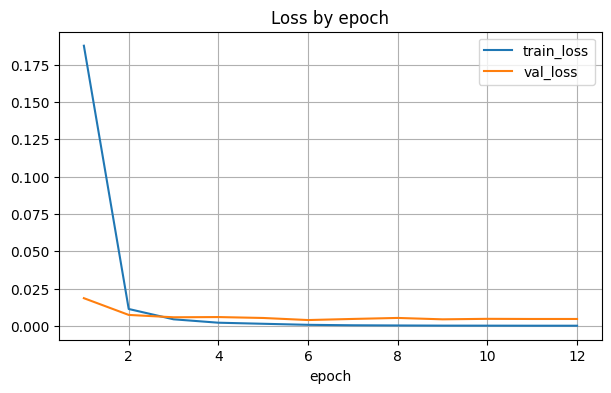

In [ ]:
df = pd.read_csv(OUTDIR / f'history_{MODEL_NAME}.csv')
fig, ax = plt.subplots(1,1, figsize=(7,4))
for split in ['train','val']:
    ax.plot(df[df.split==split]['epoch'], df[df.split==split]['loss'], label=f'{split}_loss')
ax.set_title('Loss by epoch'); ax.set_xlabel('epoch'); ax.grid(True); ax.legend()
plt.savefig(OUTDIR / f'loss_curve_{MODEL_NAME}.png', bbox_inches='tight'); plt.show()

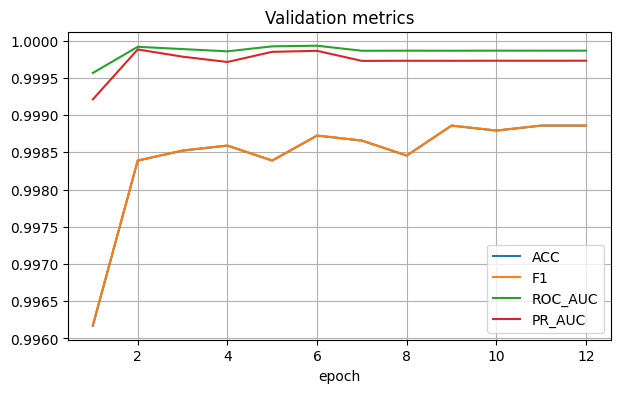

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(7,4))
for metric in ['acc','f1','roc_auc','pr_auc']:
    sub = df[df.split=='val']
    ax.plot(sub['epoch'], sub[metric], label=metric.upper())
ax.set_title('Validation metrics'); ax.set_xlabel('epoch'); ax.grid(True); ax.legend()
plt.savefig(OUTDIR / f'val_metrics_{MODEL_NAME}.png', bbox_inches='tight'); plt.show()

# Final Test Evaluation

In [ ]:
best_path = OUTDIR / f"best_{MODEL_NAME}.pt"
model.load_state_dict(torch.load(best_path, map_location=DEVICE))

@torch.no_grad()
def predict_loader(loader):
    model.eval()
    y_true, y_prob = [], []
    for x1, x2, y in tqdm(loader, desc="Test"):
        x1 = x1.to(DEVICE); x2 = x2.to(DEVICE)
        logit = model(x1, x2)
        prob = torch.sigmoid(logit).cpu().numpy()
        y_prob.extend(prob.tolist()); y_true.extend(y.numpy().tolist())
    return np.array(y_true), np.array(y_prob)

y_true, y_prob = predict_loader(dl_test)
test_metrics = compute_metrics(y_true, y_prob)
print("TEST METRICS:", json.dumps(test_metrics, indent=2))

with open(OUTDIR / f'test_metrics_{MODEL_NAME}.json','w') as f:
    json.dump(test_metrics, f, indent=2)

Test:   0%|          | 0/117 [00:00<?, ?it/s]

TEST METRICS: {
  "acc": 0.9989928830401504,
  "prec": 0.9979898150629858,
  "rec": 1.0,
  "f1": 0.9989938963042457,
  "roc_auc": 0.9999843394462267,
  "pr_auc": 0.9999834106293973
}


# Qualitative: Show TP / FP / FN Clauses Pairs

In [ ]:
def sample_qualitative(df, enc, pairs, y_prob, y_true, k=5):
    records = []
    for i, (a,b,_) in enumerate(pairs):
        prob = y_prob[i]; true = int(y_true[i]); pred = int(prob >= 0.5)
        tag = 'TP' if (pred==1 and true==1) else ('TN' if (pred==0 and true==0) else ('FP' if pred==1 else 'FN'))
        records.append((tag, prob, df.iloc[a]['text'], df.iloc[b]['text'], df.iloc[a]['type'], df.iloc[b]['type']))
    # pick examples
    out = {'TP':[], 'FP':[], 'FN':[]}
    for tag in out.keys():
        cand = [r for r in records if r[0]==tag]
        cand = sorted(cand, key=lambda x: x[1], reverse=(tag!='FN'))[:k]
        out[tag] = cand
    return out

# Rebuild test predictions in-order to align with `test_pairs`
@torch.no_grad()
def predict_pairs(pairs, enc):
    model.eval()
    B = 256
    probs, truths = [], []
    for i in range(0, len(pairs), B):
        batch = pairs[i:i+B]
        x1 = torch.tensor([enc[a] for a,b,_ in batch], dtype=torch.long, device=DEVICE)
        x2 = torch.tensor([enc[b] for a,b,_ in batch], dtype=torch.long, device=DEVICE)
        logit = model(x1, x2)
        probs.extend(torch.sigmoid(logit).cpu().numpy().tolist())
        truths.extend([y for _,_,y in batch])
    return np.array(truths), np.array(probs)

truths, probs = predict_pairs(test_pairs, test_enc)
ql = sample_qualitative(test_df, test_enc, test_pairs, probs, truths, k=5)

def pretty(snippet, width=100):
    return textwrap.fill(snippet, width=width)

for tag in ['TP','FP','FN']:
    print(f"\n=== {tag} examples ===")
    for (tg, p, a, b, ta, tb) in ql[tag]:
        print(f"[{tg}] p={p:.3f} | typeA={ta} | typeB={tb}")
        print("A:", pretty(a))
        print("B:", pretty(b))
        print("-"*80)

with open(OUTDIR / f'qual_{MODEL_NAME}.txt', 'w', encoding='utf-8') as f:
    for tag in ['TP','FP','FN']:
        f.write(f"\n=== {tag} examples ===\n")
        for (tg, p, a, b, ta, tb) in ql[tag]:
            f.write(f"[{tg}] p={p:.3f} | typeA={ta} | typeB={tb}\nA: {a}\nB: {b}\n" + "-"*80 + "\n")
print("Saved qualitative examples to:", OUTDIR / f'qual_{MODEL_NAME}.txt')

/tmp/ipython-input-3586273028.py:23: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  x1 = torch.tensor([enc[a] for a,b,_ in batch], dtype=torch.long, device=DEVICE)



=== TP examples ===
[TP] p=1.000 | typeA=time | typeB=time
A: Time. Time is of the essence as to all provisions in this Lease in which time is a factor.
B: Time. Time is of the essence with respect to the performance of every provision of this Lease in
which time of performance is a factor.
--------------------------------------------------------------------------------
[TP] p=1.000 | typeA=use-of-proceeds | typeB=use-of-proceeds
A: Use of Proceeds. Use the proceeds of the Borrowings and the Letters of Credit for general corporate
purposes including (i) financing, in part, investments by and capital expenditures of the Borrower
and its Subsidiaries, (ii) subject to the terms and conditions of this Agreement, repurchases of
Common Equity of the Borrower and/or investments in nonregulated and/or nonutility businesses and
(iii) financing working capital requirements of the Borrower and its Subsidiaries.
B: Use of Proceeds. The Company shall use the proceeds from the sale of -------------

# Confusion Matrix Visualization (Test set)

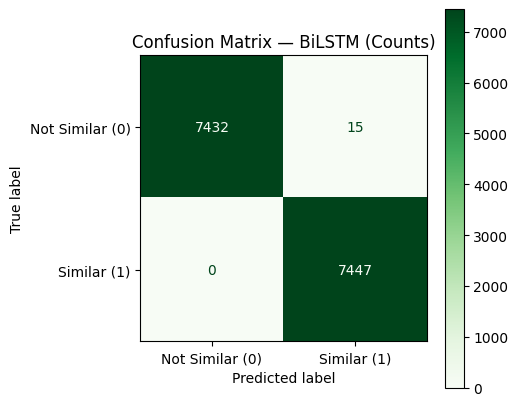

Saved: /content/outputs/confusion_matrix_counts_BiLSTM.png


In [ ]:
try:
    y_true, y_prob
except NameError:
    @torch.no_grad()
    def _predict_pairs(pairs, enc):
        model.eval()
        B = 256
        probs, truths = [], []
        for i in range(0, len(pairs), B):
            batch = pairs[i:i+B]
            x1 = torch.tensor([enc[a] for a,b,_ in batch], dtype=torch.long, device=DEVICE)
            x2 = torch.tensor([enc[b] for a,b,_ in batch], dtype=torch.long, device=DEVICE)
            logit = model(x1, x2)
            probs.extend(torch.sigmoid(logit).cpu().numpy().tolist())
            truths.extend([y for _,_,y in batch])
        return np.array(truths), np.array(probs)

    y_true, y_prob = _predict_pairs(test_pairs, test_enc)

# 2) Binarize with the default 0.5 threshold (adjust if you tuned a different threshold)
y_pred = (y_prob >= 0.5).astype(int)

# 3) Build confusion matrices (raw counts and normalized)
labels = [0, 1]
display_labels = ['Not Similar (0)', 'Similar (1)']

cm = confusion_matrix(y_true, y_pred, labels=labels)
#cm_norm = confusion_matrix(y_true, y_pred, labels=labels, normalize='true')

# 4) Plot — Counts
fig1, ax1 = plt.subplots(figsize=(5.2, 4.5))
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
disp1.plot(ax=ax1, cmap='Greens', colorbar=True, values_format='d')
ax1.set_title(f'Confusion Matrix — {MODEL_NAME} (Counts)')
plt.tight_layout()
counts_path = OUTDIR / f'confusion_matrix_counts_{MODEL_NAME}.png'
plt.savefig(counts_path, bbox_inches='tight', dpi=300)
plt.show()

# # 5) Plot — Normalized (per true class)
# fig2, ax2 = plt.subplots(figsize=(5.2, 4.5))
# disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=display_labels)
# disp2.plot(ax=ax2, cmap='Greens', colorbar=True, values_format='.2f')
# ax2.set_title(f'Confusion Matrix — {MODEL_NAME} (Normalized)')
# plt.tight_layout()
# norm_path = OUTDIR / f'confusion_matrix_norm_{MODEL_NAME}.png'
# plt.savefig(norm_path, bbox_inches='tight', dpi=300)
# plt.show()

print("Saved:", counts_path)
# print("Saved:", norm_path)

# Saving Results & Quick Summary

In [ ]:
summary = {
    "model": MODEL_NAME,
    "vocab_size": vocab_size,
    "max_len": cfg["max_len"],
    "epochs": cfg["epochs"],
    "optimizer": "AdamW",
    "lr": cfg["lr"],
    "weight_decay": cfg["weight_decay"],
    "train_pairs": len(train_pairs),
    "val_pairs": len(val_pairs),
    "test_pairs": len(test_pairs)
}
with open(OUTDIR / f'summary_{MODEL_NAME}.json','w') as f:
    json.dump(summary, f, indent=2)

print("Artifacts:")
for p in sorted(OUTDIR.glob('*')):
    print("-", p.name)

Artifacts:
- best_BiLSTM.pt
- confusion_matrix_counts_BiLSTM.png
- history_BiLSTM.csv
- loss_curve_BiLSTM.png
- qual_BiLSTM.txt
- summary_BiLSTM.json
- test_metrics_BiLSTM.json
- val_metrics_BiLSTM.png


# Checking SiameseAttnCNN Model Parameters

In [14]:
# Helper to quickly switch model and re-train without re-running earlier cells:
MODEL_NAME = "AttCNN"   # change to: "attncnn" to train the other baseline

if MODEL_NAME == "BiLSTM":
    model = SiameseBiLSTM(vocab_size=vocab_size).to(DEVICE)
elif MODEL_NAME == "AttCNN":
    model = SiameseAttnCNN(vocab_size=vocab_size, d_model=256, ks=(3,4,5)).to(DEVICE)
else:
    raise ValueError("Unknown model name")

criterion = nn.BCEWithLogitsLoss()
optimizer = AdamW(model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg["epochs"])
scaler = GradScaler(enabled=cfg["amp"])
history = {"epoch":[], "split":[], "loss":[], "acc":[], "prec":[], "rec":[], "f1":[], "roc_auc":[], "pr_auc":[]}
best_f1 = -1

sum_params = sum(p.numel() for p in model.parameters())/1e6
print(f"Model: {model.__class__.__name__} | Params: {sum_params:.2f}M")

Model: SiameseAttnCNN | Params: 5.97M


/tmp/ipython-input-966659289.py:14: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=cfg["amp"])


# Training and Evaluating Attention CNN Encoder

In [15]:
def run_epoch(loader, train=True):
    model.train(train)
    losses, y_true, y_prob = [], [], []
    pbar = tqdm(loader, desc="Train" if train else "Eval")

    for x1, x2, y in pbar:
        x1 = x1.to(DEVICE, non_blocking=True)
        x2 = x2.to(DEVICE, non_blocking=True)
        y  = y.to(DEVICE, non_blocking=True)

        if train:
            optimizer.zero_grad(set_to_none=True)

        # Use new autocast API
        with torch.amp.autocast('cuda', enabled=cfg["amp"]):
            logit = model(x1, x2)
            loss  = criterion(logit, y)

        if train:
            # Correct GradScaler order
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

        losses.append(loss.item())
        probs = torch.sigmoid(logit).detach().cpu().numpy()
        y_prob.extend(probs.tolist())
        y_true.extend(y.detach().cpu().numpy().tolist())

        pbar.set_postfix(loss=float(np.mean(losses)))

    metrics = compute_metrics(y_true, y_prob)
    return float(np.mean(losses)), metrics

history = {"epoch":[], "split":[], "loss":[], "acc":[], "prec":[], "rec":[], "f1":[], "roc_auc":[], "pr_auc":[]}
best_f1 = -1; best_path = OUTDIR / f"best_{MODEL_NAME}.pt"

for epoch in range(1, cfg["epochs"]+1):
    tl, tmet = run_epoch(dl_train, train=True)
    vl, vmet = run_epoch(dl_val,   train=False)
    scheduler.step()

    print(f"Epoch {epoch:02d} | Train loss {tl:.4f} | Val loss {vl:.4f} | "
          f"Val F1 {vmet['f1']:.4f} | Val Acc {vmet['acc']:.4f} | Val ROC-AUC {vmet['roc_auc']:.4f}")

    for split, loss, met in [('train', tl, tmet), ('val', vl, vmet)]:
        history["epoch"].append(epoch)
        history["split"].append(split)
        history["loss"].append(loss)
        for k in ['acc','prec','rec','f1','roc_auc','pr_auc']:
            history.setdefault(k, None)
            history[k].append(met[k])

    if vmet["f1"] > best_f1:
        best_f1 = vmet["f1"]
        torch.save(model.state_dict(), best_path)

hist_df = pd.DataFrame(history)
hist_df.to_csv(OUTDIR / f'history_{MODEL_NAME}.csv', index=False)
print("Best Val F1:", best_f1, "| Saved:", best_path)

Train:   0%|          | 0/940 [00:00<?, ?it/s]

Eval:   0%|          | 0/117 [00:00<?, ?it/s]

Epoch 01 | Train loss 0.3960 | Val loss 0.1731 | Val F1 0.9410 | Val Acc 0.9381 | Val ROC-AUC 0.9755


Train:   0%|          | 0/940 [00:00<?, ?it/s]

Eval:   0%|          | 0/117 [00:00<?, ?it/s]

...

Eval:   0%|          | 0/117 [00:00<?, ?it/s]

Epoch 11 | Train loss 0.0032 | Val loss 0.0200 | Val F1 0.9946 | Val Acc 0.9946 | Val ROC-AUC 0.9995


Train:   0%|          | 0/940 [00:00<?, ?it/s]

Eval:   0%|          | 0/117 [00:00<?, ?it/s]

Epoch 12 | Train loss 0.0028 | Val loss 0.0196 | Val F1 0.9946 | Val Acc 0.9946 | Val ROC-AUC 0.9995
Best Val F1: 0.9954515050167224 | Saved: /content/outputs/best_AttCNN.pt


# Training Curves

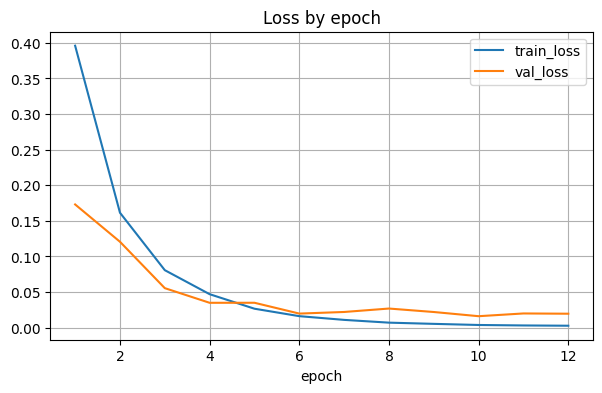

In [16]:
df = pd.read_csv(OUTDIR / f'history_{MODEL_NAME}.csv')
fig, ax = plt.subplots(1,1, figsize=(7,4))
for split in ['train','val']:
    ax.plot(df[df.split==split]['epoch'], df[df.split==split]['loss'], label=f'{split}_loss')
ax.set_title('Loss by epoch'); ax.set_xlabel('epoch'); ax.grid(True); ax.legend()
plt.savefig(OUTDIR / f'loss_curve_{MODEL_NAME}.png', bbox_inches='tight'); plt.show()

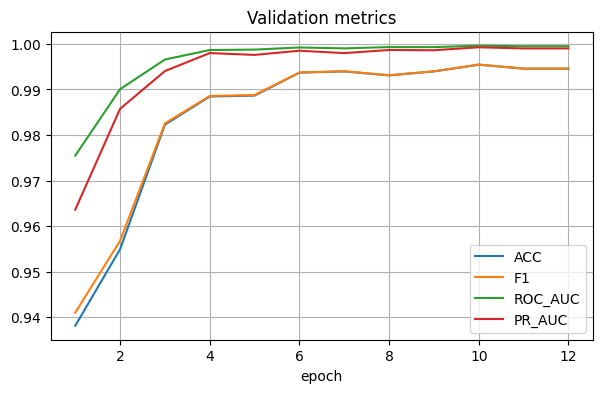

In [17]:
fig, ax = plt.subplots(1,1, figsize=(7,4))
for metric in ['acc','f1','roc_auc','pr_auc']:
    sub = df[df.split=='val']
    ax.plot(sub['epoch'], sub[metric], label=metric.upper())
ax.set_title('Validation metrics'); ax.set_xlabel('epoch'); ax.grid(True); ax.legend()
plt.savefig(OUTDIR / f'val_metrics_{MODEL_NAME}.png', bbox_inches='tight'); plt.show()

# Final Test Evaluation

In [18]:
best_path = OUTDIR / f"best_{MODEL_NAME}.pt"
model.load_state_dict(torch.load(best_path, map_location=DEVICE))

@torch.no_grad()
def predict_loader(loader):
    model.eval()
    y_true, y_prob = [], []
    for x1, x2, y in tqdm(loader, desc="Test"):
        x1 = x1.to(DEVICE); x2 = x2.to(DEVICE)
        logit = model(x1, x2)
        prob = torch.sigmoid(logit).cpu().numpy()
        y_prob.extend(prob.tolist()); y_true.extend(y.numpy().tolist())
    return np.array(y_true), np.array(y_prob)

y_true, y_prob = predict_loader(dl_test)
test_metrics = compute_metrics(y_true, y_prob)
print("TEST METRICS:", json.dumps(test_metrics, indent=2))

with open(OUTDIR / f'test_metrics_{MODEL_NAME}.json','w') as f:
    json.dump(test_metrics, f, indent=2)

Test:   0%|          | 0/117 [00:00<?, ?it/s]

TEST METRICS: {
  "acc": 0.9955015442460051,
  "prec": 0.9916067146282974,
  "rec": 0.9994628709547468,
  "f1": 0.9955192937871999,
  "roc_auc": 0.9997224917414245,
  "pr_auc": 0.999278783901114
}


# Qualitative: Show TP / FP / FN Clauses Pairs

In [19]:
def sample_qualitative(df, enc, pairs, y_prob, y_true, k=5):
    records = []
    for i, (a,b,_) in enumerate(pairs):
        prob = y_prob[i]; true = int(y_true[i]); pred = int(prob >= 0.5)
        tag = 'TP' if (pred==1 and true==1) else ('TN' if (pred==0 and true==0) else ('FP' if pred==1 else 'FN'))
        records.append((tag, prob, df.iloc[a]['text'], df.iloc[b]['text'], df.iloc[a]['type'], df.iloc[b]['type']))
    # pick examples
    out = {'TP':[], 'FP':[], 'FN':[]}
    for tag in out.keys():
        cand = [r for r in records if r[0]==tag]
        cand = sorted(cand, key=lambda x: x[1], reverse=(tag!='FN'))[:k]
        out[tag] = cand
    return out

# Rebuild test predictions in-order to align with `test_pairs`
@torch.no_grad()
def predict_pairs(pairs, enc):
    model.eval()
    B = 256
    probs, truths = [], []
    for i in range(0, len(pairs), B):
        batch = pairs[i:i+B]
        x1 = torch.tensor([enc[a] for a,b,_ in batch], dtype=torch.long, device=DEVICE)
        x2 = torch.tensor([enc[b] for a,b,_ in batch], dtype=torch.long, device=DEVICE)
        logit = model(x1, x2)
        probs.extend(torch.sigmoid(logit).cpu().numpy().tolist())
        truths.extend([y for _,_,y in batch])
    return np.array(truths), np.array(probs)

truths, probs = predict_pairs(test_pairs, test_enc)
ql = sample_qualitative(test_df, test_enc, test_pairs, probs, truths, k=5)

def pretty(snippet, width=100):
    return textwrap.fill(snippet, width=width)

for tag in ['TP','FP','FN']:
    print(f"\n=== {tag} examples ===")
    for (tg, p, a, b, ta, tb) in ql[tag]:
        print(f"[{tg}] p={p:.3f} | typeA={ta} | typeB={tb}")
        print("A:", pretty(a))
        print("B:", pretty(b))
        print("-"*80)

with open(OUTDIR / f'qual_{MODEL_NAME}.txt', 'w', encoding='utf-8') as f:
    for tag in ['TP','FP','FN']:
        f.write(f"\n=== {tag} examples ===\n")
        for (tg, p, a, b, ta, tb) in ql[tag]:
            f.write(f"[{tg}] p={p:.3f} | typeA={ta} | typeB={tb}\nA: {a}\nB: {b}\n" + "-"*80 + "\n")
print("Saved qualitative examples to:", OUTDIR / f'qual_{MODEL_NAME}.txt')

/tmp/ipython-input-3586273028.py:23: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  x1 = torch.tensor([enc[a] for a,b,_ in batch], dtype=torch.long, device=DEVICE)



=== TP examples ===
[TP] p=1.000 | typeA=definitions-and-interpretation | typeB=definitions-and-interpretation
A: Definitions and Interpretation. 1.1. In this Agreement the following definitions apply:
B: Definitions and Interpretation. 1.1 In this Agreement, unless the context requires otherwise, the
capitalised terms set out below have the following meanings:
--------------------------------------------------------------------------------
[TP] p=1.000 | typeA=definitions-and-interpretation | typeB=definitions-and-interpretation
A: Definitions and Interpretation. 15.1 In this Agreement (except where the context otherwise requires)
the words and expressions beginning with capital letters shall have the meanings given to them in
the Glossary at the end of this Agreement.
B: Definitions and Interpretation. 2.1 All capitalised terms in these TERMS AND CONDITIONS shall have
the definitions given to them in this CLAUSE 2 or in the CLAUSE in which they are stated. References
to “CLAUSES” in

# Confusion Matrix Visualization (Test set)

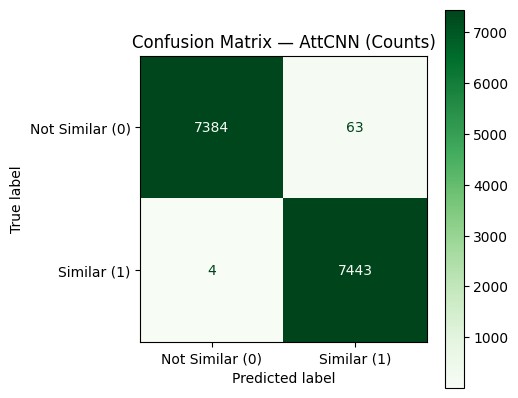

Saved: /content/outputs/confusion_matrix_counts_AttCNN.png


In [20]:
try:
    y_true, y_prob
except NameError:
    @torch.no_grad()
    def _predict_pairs(pairs, enc):
        model.eval()
        B = 256
        probs, truths = [], []
        for i in range(0, len(pairs), B):
            batch = pairs[i:i+B]
            x1 = torch.tensor([enc[a] for a,b,_ in batch], dtype=torch.long, device=DEVICE)
            x2 = torch.tensor([enc[b] for a,b,_ in batch], dtype=torch.long, device=DEVICE)
            logit = model(x1, x2)
            probs.extend(torch.sigmoid(logit).cpu().numpy().tolist())
            truths.extend([y for _,_,y in batch])
        return np.array(truths), np.array(probs)

    y_true, y_prob = _predict_pairs(test_pairs, test_enc)

# 2) Binarize with the default 0.5 threshold (adjust if you tuned a different threshold)
y_pred = (y_prob >= 0.5).astype(int)

# 3) Build confusion matrices (raw counts and normalized)
labels = [0, 1]
display_labels = ['Not Similar (0)', 'Similar (1)']

cm = confusion_matrix(y_true, y_pred, labels=labels)
# cm_norm = confusion_matrix(y_true, y_pred, labels=labels, normalize='true')

# 4) Plot — Counts
fig1, ax1 = plt.subplots(figsize=(5.2, 4.5))
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
disp1.plot(ax=ax1, cmap='Greens', colorbar=True, values_format='d')
ax1.set_title(f'Confusion Matrix — {MODEL_NAME} (Counts)')
plt.tight_layout()
counts_path = OUTDIR / f'confusion_matrix_counts_{MODEL_NAME}.png'
plt.savefig(counts_path, bbox_inches='tight', dpi=300)
plt.show()

# # 5) Plot — Normalized (per true class)
# fig2, ax2 = plt.subplots(figsize=(5.2, 4.5))
# disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=display_labels)
# disp2.plot(ax=ax2, cmap='Greens', colorbar=True, values_format='.2f')
# ax2.set_title(f'Confusion Matrix — {MODEL_NAME} (Normalized)')
# plt.tight_layout()
# norm_path = OUTDIR / f'confusion_matrix_norm_{MODEL_NAME}.png'
# plt.savefig(norm_path, bbox_inches='tight', dpi=300)
# plt.show()

print("Saved:", counts_path)
# print("Saved:", norm_path)

# Saving Results & Quick Summary

In [21]:
summary = {
    "model": MODEL_NAME,
    "vocab_size": vocab_size,
    "max_len": cfg["max_len"],
    "epochs": cfg["epochs"],
    "optimizer": "AdamW",
    "lr": cfg["lr"],
    "weight_decay": cfg["weight_decay"],
    "train_pairs": len(train_pairs),
    "val_pairs": len(val_pairs),
    "test_pairs": len(test_pairs)
}
with open(OUTDIR / f'summary_{MODEL_NAME}.json','w') as f:
    json.dump(summary, f, indent=2)

print("Artifacts:")
for p in sorted(OUTDIR.glob('*')):
    print("-", p.name)

Artifacts:
- best_AttCNN.pt
- confusion_matrix_counts_AttCNN.png
- history_AttCNN.csv
- loss_curve_AttCNN.png
- qual_AttCNN.txt
- summary_AttCNN.json
- test_metrics_AttCNN.json
- val_metrics_AttCNN.png
